In [6]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [7]:
# load data
df = pd.read_csv('diabetes.csv')
print(df.head())
print("Shape:", df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape: (768, 9)


In [8]:
# check for zeros that should be NaN
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    print(f"{col} zeros: {(df[col] == 0).sum()}")

# replace 0s with NaN
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

print("\nMissing vals:", df.isnull().sum())

Glucose zeros: 5
BloodPressure zeros: 35
SkinThickness zeros: 227
Insulin zeros: 374
BMI zeros: 11

Missing vals: Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


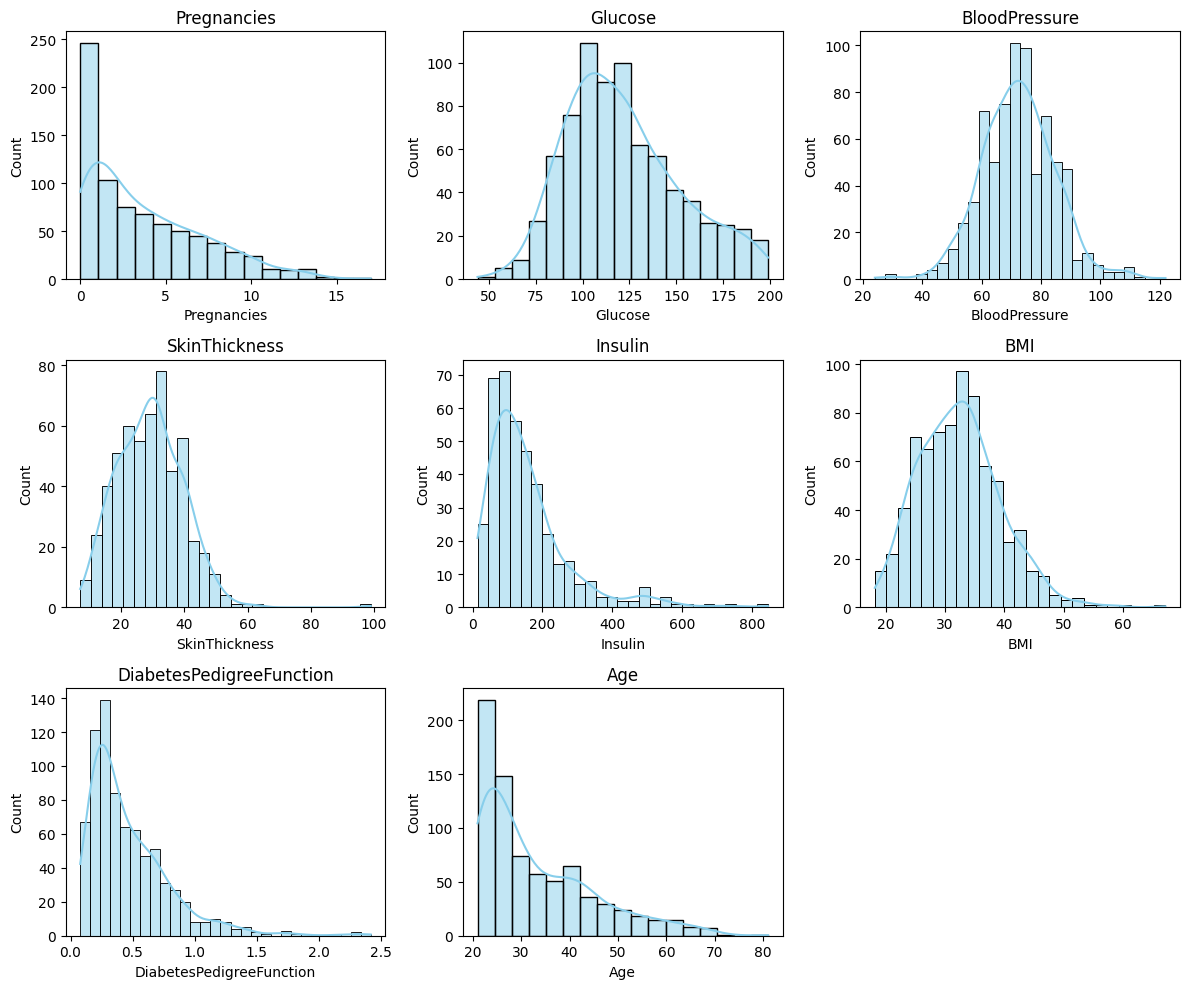

In [9]:
# visualize data
plt.figure(figsize=(12, 10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()


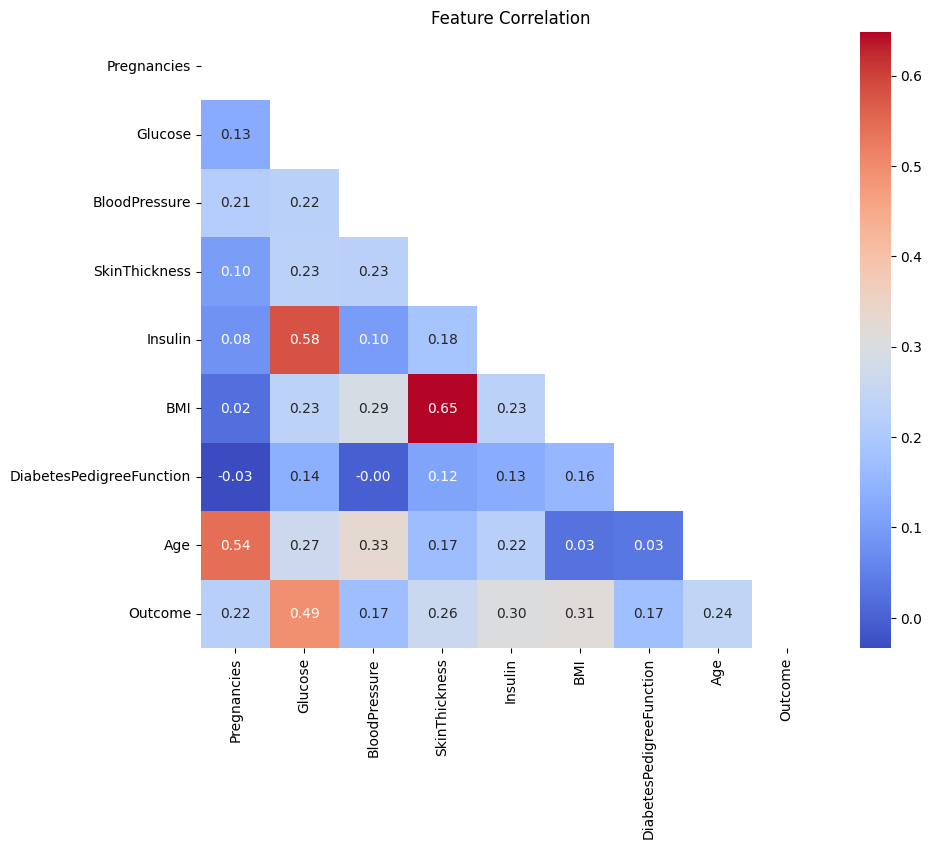

In [10]:
# corr heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


In [11]:
# preprocess func
def preproc(df):
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']

    # impute missing vals
    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

    # scale features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X_imp.columns)

    return X_scaled, y, X_imp


In [12]:
# baseline model
X, y, _ = preproc(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train baseline model
base_model = RandomForestClassifier(n_estimators=100, random_state=42)
base_model.fit(X_train, y_train)
y_pred = base_model.predict(X_test)

# metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline metrics:")
print(f"Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")


Baseline metrics:
Acc: 0.7403, Prec: 0.6316, Rec: 0.6545, F1: 0.6429


Top features (filter):
                    Feature       Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


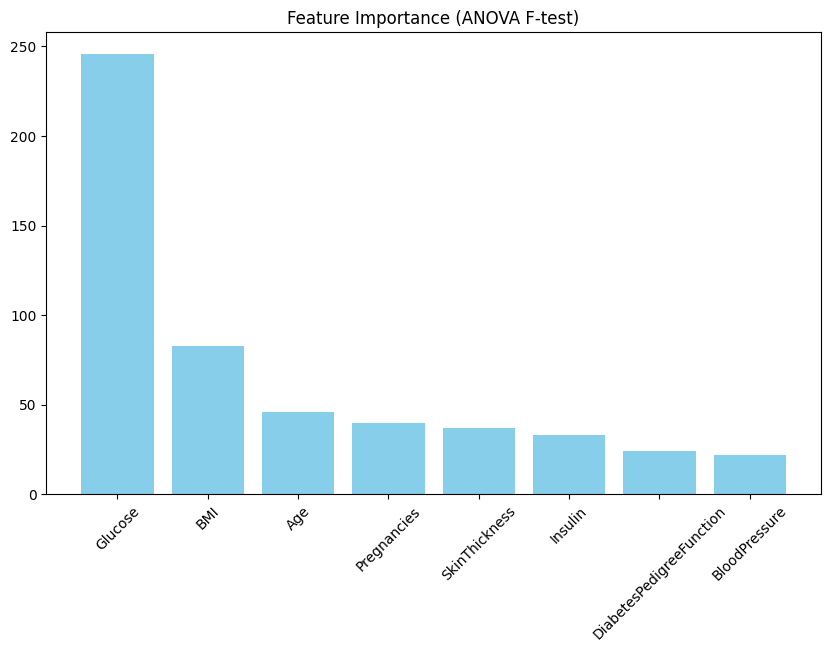

In [13]:
# feature selection - filter method
X, y, X_imp = preproc(df)

# SelectKBest
selector = SelectKBest(f_classif, k=5)
X_new = selector.fit_transform(X_imp, y)

# get scores
scores = pd.DataFrame({
    'Feature': X_imp.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("Top features (filter):")
print(scores)

# viz
plt.figure(figsize=(10, 6))
plt.bar(scores['Feature'], scores['Score'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Feature Importance (ANOVA F-test)')
plt.show()


Top features (RFE):
                    Feature  Selected  Rank
1                   Glucose      True     1
6  DiabetesPedigreeFunction      True     1
5                       BMI      True     1
4                   Insulin      True     1
7                       Age      True     1
2             BloodPressure     False     2
0               Pregnancies     False     3
3             SkinThickness     False     4


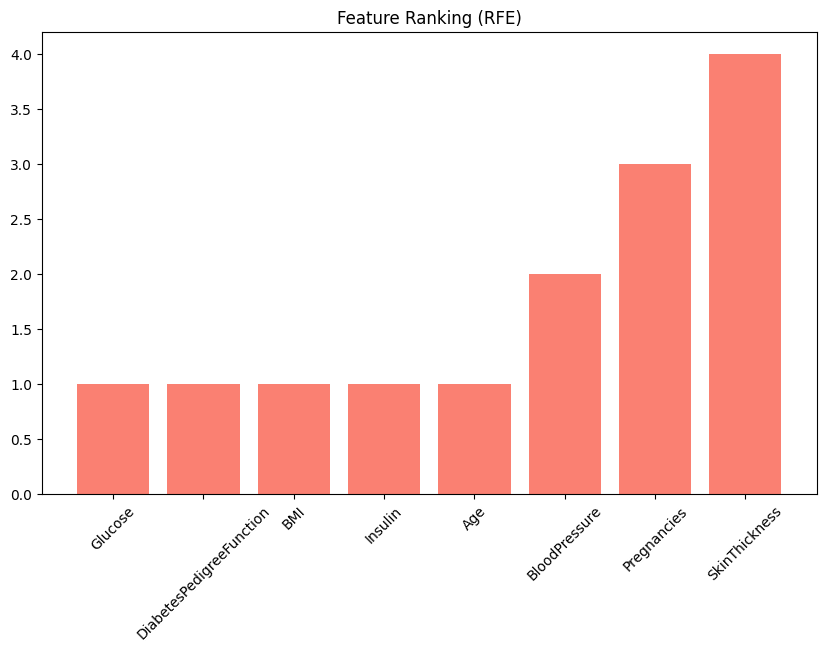

In [14]:
# feature selection - wrapper method
X, y, X_imp = preproc(df)

# RFE
rfe_model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rfe_model, n_features_to_select=5)
X_rfe = rfe.fit_transform(X_imp, y)

# selected feats
rfe_feats = pd.DataFrame({
    'Feature': X_imp.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
}).sort_values('Rank')

print("Top features (RFE):")
print(rfe_feats)

# viz
plt.figure(figsize=(10, 6))
plt.bar(rfe_feats['Feature'], rfe_feats['Rank'], color='salmon')
plt.xticks(rotation=45)
plt.title('Feature Ranking (RFE)')
plt.show()


In [15]:
# handle class imbalance
X, y, X_imp = preproc(df)

print("Original class distribution:")
print(pd.Series(y).value_counts())

# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_imp, y)

print("\nAfter SMOTE:")
print(pd.Series(y_smote).value_counts())


Original class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

After SMOTE:
Outcome
1    500
0    500
Name: count, dtype: int64


In [16]:
# build model with FE
X, y, X_imp = preproc(df)

# get best feats from RFE
rfe = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=5)
rfe.fit(X_imp, y)
best_feats = X_imp.columns[rfe.support_].tolist()

print("Selected features:", best_feats)

# prepare data with best feats
X_best = X_imp[best_feats]

# apply SMOTE
smote = SMOTE(random_state=42)
X_best_smote, y_smote = smote.fit_resample(X_best, y)

# split
X_train, X_test, y_train, y_test = train_test_split(X_best_smote, y_smote, test_size=0.2, random_state=42)

# train model
fe_model = RandomForestClassifier(n_estimators=100, random_state=42)
fe_model.fit(X_train, y_train)
y_pred = fe_model.predict(X_test)

# metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("FE model metrics:")
print(f"Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")


Selected features: ['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
FE model metrics:
Acc: 0.7650, Prec: 0.7647, Rec: 0.7723, F1: 0.7685


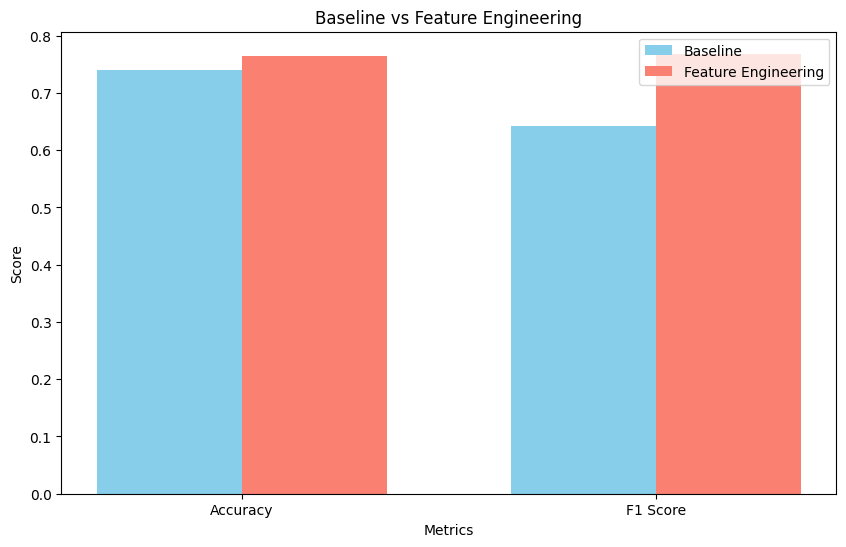

In [17]:
# compare baseline vs FE
# train baseline on same split for fair comparison
base_model = RandomForestClassifier(n_estimators=100, random_state=42)
X_all, y_all, _ = preproc(df)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
base_model.fit(X_train_base, y_train_base)
y_pred_base = base_model.predict(X_test_base)

base_metrics = {
    'acc': accuracy_score(y_test_base, y_pred_base),
    'f1': f1_score(y_test_base, y_pred_base)
}

fe_metrics = {
    'acc': acc,
    'f1': f1
}

# viz comparison
plt.figure(figsize=(10, 6))
metrics = ['acc', 'f1']
base_vals = [base_metrics[m] for m in metrics]
fe_vals = [fe_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, base_vals, width, label='Baseline', color='skyblue')
plt.bar(x + width/2, fe_vals, width, label='Feature Engineering', color='salmon')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Baseline vs Feature Engineering')
plt.xticks(x, ['Accuracy', 'F1 Score'])
plt.legend()
plt.show()


Feature importance:
                    Feature  Importance
0                   Glucose    0.305063
2                       BMI    0.227580
4                       Age    0.210236
3  DiabetesPedigreeFunction    0.149263
1                   Insulin    0.107858


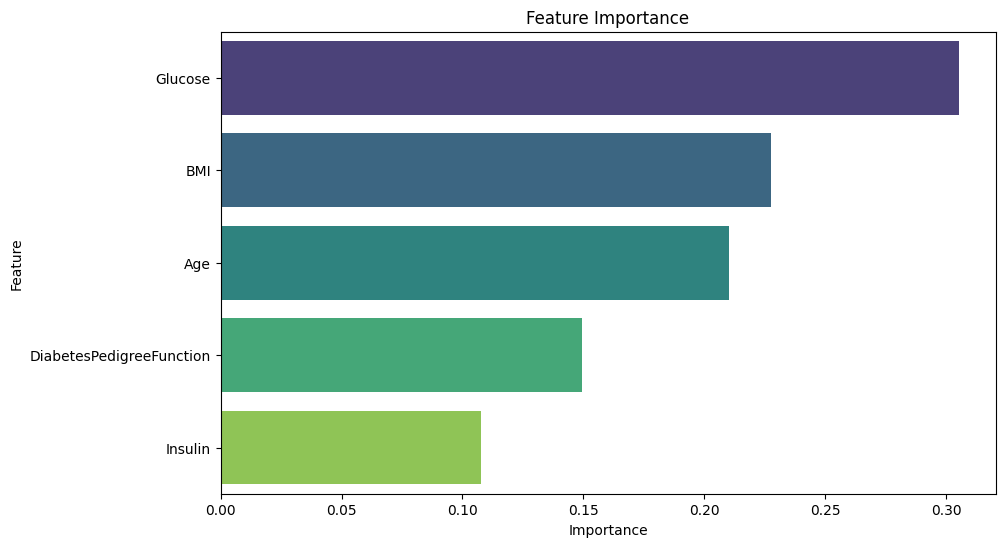

In [18]:
# feature importance
importances = fe_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': best_feats,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature importance:")
print(feat_imp)

# viz
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Feature Importance')
plt.show()


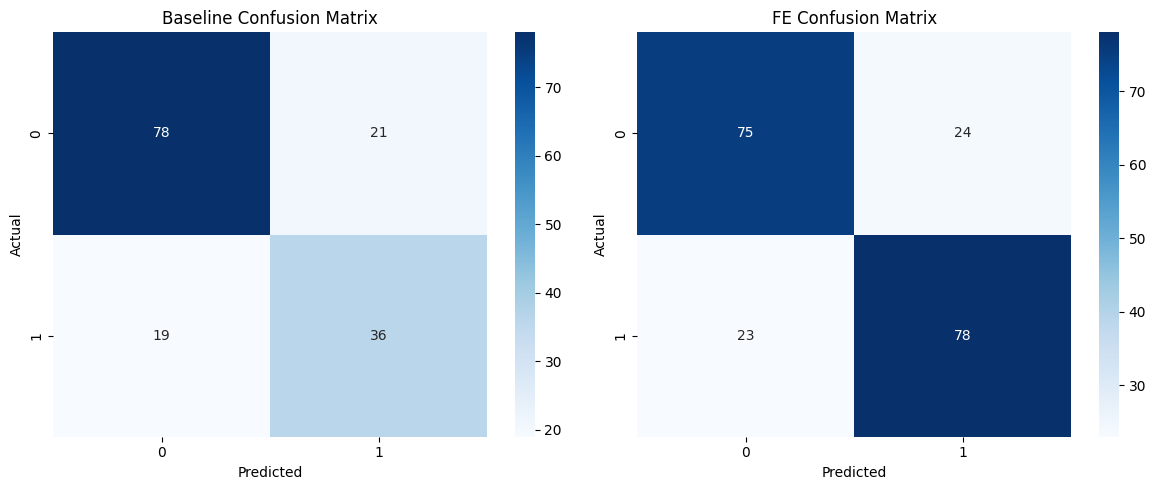

In [19]:
# confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# baseline cm
cm_base = confusion_matrix(y_test_base, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Baseline Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# fe cm
cm_fe = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_fe, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('FE Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()


Logistic Regression metrics:
Acc: 0.7300, F1: 0.7273

Feature coefficients:
                    Feature  Coefficient
3  DiabetesPedigreeFunction     0.726284
2                       BMI     0.092800
0                   Glucose     0.039633
4                       Age     0.032507
1                   Insulin    -0.001747


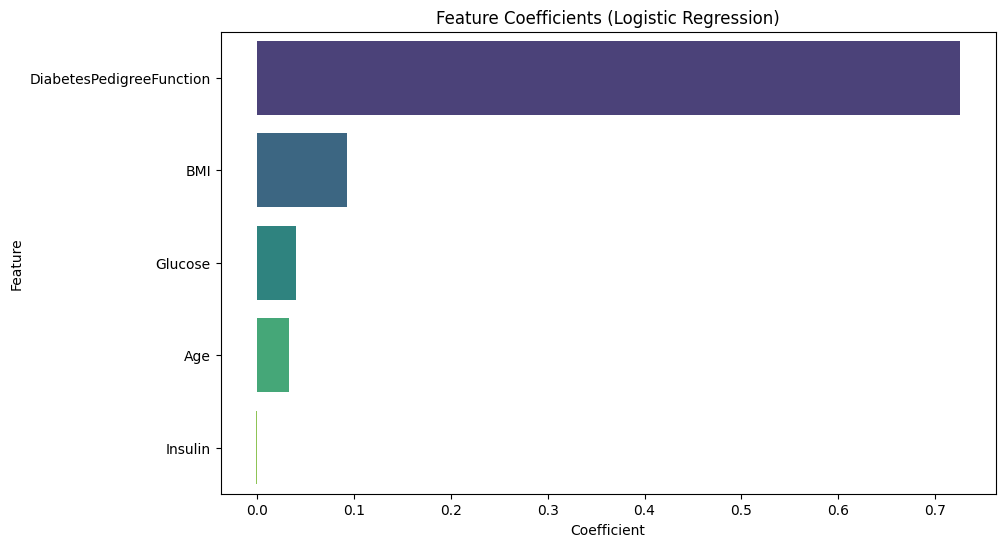

In [20]:
# try logistic regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression metrics:")
print(f"Acc: {acc_lr:.4f}, F1: {f1_lr:.4f}")

# get coeffs
coefs = lr_model.coef_[0]
coef_df = pd.DataFrame({
    'Feature': best_feats,
    'Coefficient': coefs
}).sort_values('Coefficient', ascending=False)

print("\nFeature coefficients:")
print(coef_df)

# viz
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Coefficients (Logistic Regression)')
plt.show()


In [21]:
# final summary
print("Feature Engineering Summary:")
print("\nSelected Features:", best_feats)
print("\nBaseline vs Feature Engineering:")
print(f"Baseline - Acc: {base_metrics['acc']:.4f}, F1: {base_metrics['f1']:.4f}")
print(f"FE       - Acc: {fe_metrics['acc']:.4f}, F1: {fe_metrics['f1']:.4f}")

# calc improvement
acc_imp = (fe_metrics['acc'] - base_metrics['acc']) / base_metrics['acc'] * 100
f1_imp = (fe_metrics['f1'] - base_metrics['f1']) / base_metrics['f1'] * 100

print(f"Improvement - Acc: {acc_imp:.2f}%, F1: {f1_imp:.2f}%")


Feature Engineering Summary:

Selected Features: ['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Baseline vs Feature Engineering:
Baseline - Acc: 0.7403, F1: 0.6429
FE       - Acc: 0.7650, F1: 0.7685
Improvement - Acc: 3.34%, F1: 19.54%
